<img width="1279" height="665" alt="Image" src="https://github.com/user-attachments/assets/2df7160f-bbcf-4d04-8d30-73021a236606" />

<div style="
    padding: 20px;
    color: white;
    margin: 0;
    font-size: 300%;
    font-weight: 800;
    text-align: center;
    display: fill;
    border-radius: 60px;
    background-color: #D8CEF6;
    box-shadow: 0 4px 8px rgba(0, 0, 0, 0.2);
    text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.5);
">
    Predict Student Success  <br>
</div>

# <div style="display: inline-block; padding: 20px 20px; border-radius: 15px; background: linear-gradient(135deg, #d8bfd8, #8b008b); box-shadow: 3px 3px 8px rgba(0, 0, 0, 0.2); font-size: 35px; font-family: Arial, sans-serif; color: #ffffff; text-align: center;">Import Libraries & Read Dataset</div>

In [1]:
# For EDA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, RobustScaler

# For Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression, BayesianRidge
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.exceptions import FitFailedWarning

# For Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Conv1D, MaxPooling1D, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

2026-02-06 12:10:01.961722: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770379802.242917      17 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770379802.329859      17 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770379802.999770      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770379802.999828      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770379802.999831      17 computation_placer.cc:177] computation placer alr

In [2]:
df = pd.read_csv("/kaggle/input/student/student_performance_interactions.csv")
df.head()

,student_id,final_score,grade,pass_fail,previous_score,math_prev_score,science_prev_score,language_prev_score,daily_study_hours,attendance_percentage,homework_completion_rate,sleep_hours,screen_time_hours,physical_activity_minutes,motivation_score,exam_anxiety_score,parent_education_level,study_environment
0,S0001,60.137241,D,1,60.599707,61.488212,53.568119,64.972292,1.427203,75.738405,68.534371,6.809352,3.313096,65.059425,4.150025,6.104103,Master,Noisy
1,S0002,99.021977,A,1,92.289287,85.612565,91.873759,89.040461,4.813612,89.602736,91.990197,5.567793,4.925359,76.016617,8.714693,1.982358,High School,Quiet
2,S0003,70.522955,C,1,80.259667,82.160656,72.736065,74.243663,1.240908,81.495426,69.669666,6.702875,5.107888,113.616872,5.928220,4.463662,High School,Moderate
3,S0004,63.448537,D,1,72.926217,75.979145,76.726496,67.715995,2.190601,71.472047,71.976757,7.854439,3.772446,108.686690,4.224928,4.740474,High School,Noisy
4,S0005,66.483019,C,1,48.581025,51.379977,48.993224,46.145011,2.192265,64.276582,68.940591,7.662429,1.898989,42.107294,9.506815,1.143852,Master,Quiet


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 18 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   student_id                 1000 non-null   object 
 1   final_score                1000 non-null   float64
 2   grade                      1000 non-null   object 
 3   pass_fail                  1000 non-null   int64  
 4   previous_score             1000 non-null   float64
 5   math_prev_score            1000 non-null   float64
 6   science_prev_score         1000 non-null   float64
 7   language_prev_score        1000 non-null   float64
 8   daily_study_hours          1000 non-null   float64
 9   attendance_percentage      1000 non-null   float64
 10  homework_completion_rate   1000 non-null   float64
 11  sleep_hours                1000 non-null   float64
 12  screen_time_hours          1000 non-null   float64
 13  physical_activity_minutes  1000 non-null   float6

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
final_score,1000.0,70.935159,14.376419,37.364699,60.079082,70.673531,81.830057,100.000000
pass_fail,1000.0,0.930000,0.255275,0.000000,1.000000,1.000000,1.000000,1.000000
previous_score,1000.0,66.964110,16.067555,40.254761,52.978530,67.324406,80.937577,94.984472
math_prev_score,1000.0,67.458590,16.593689,30.235250,53.098000,67.561105,81.380928,104.984169
science_prev_score,1000.0,67.033210,17.105514,25.752553,52.509398,66.133873,81.319085,107.432492
language_prev_score,1000.0,66.906063,16.705229,27.176600,53.562773,66.693546,80.269633,107.561521
daily_study_hours,1000.0,2.984155,1.158047,1.003774,1.985539,2.934717,3.971015,4.997401
attendance_percentage,1000.0,73.275703,9.533937,47.445725,66.256237,73.328172,80.230732,99.111497
homework_completion_rate,1000.0,79.755579,12.360754,51.604853,69.964528,79.393715,89.592788,110.485203
sleep_hours,1000.0,6.964696,0.684015,4.500750,6.518039,6.976139,7.413489,9.353503


In [5]:
df.describe(include='object')

,student_id,grade,parent_education_level,study_environment
count,1000,1000,1000,1000
unique,1000,5,3,3
top,S1000,C,Master,Quiet
freq,1,338,351,337


# <div style="display: inline-block; padding: 20px 20px; border-radius: 15px; background: linear-gradient(135deg, #d8bfd8, #8b008b); box-shadow: 3px 3px 8px rgba(0, 0, 0, 0.2); font-size: 35px; font-family: Arial, sans-serif; color: #ffffff; text-align: center;">Data preprocessing</div>

In [6]:
print("Missing Value (%)")
missing_values = df.isna().mean() * 100
print(missing_values)

print("\nDuplicate Rows (%):")
duplicate_count = df.duplicated().mean()
print(duplicate_count)

Missing Value (%)
student_id                   0.0
final_score                  0.0
grade                        0.0
pass_fail                    0.0
previous_score               0.0
math_prev_score              0.0
science_prev_score           0.0
language_prev_score          0.0
daily_study_hours            0.0
attendance_percentage        0.0
homework_completion_rate     0.0
sleep_hours                  0.0
screen_time_hours            0.0
physical_activity_minutes    0.0
motivation_score             0.0
exam_anxiety_score           0.0
parent_education_level       0.0
study_environment            0.0
dtype: float64

Duplicate Rows (%):
0.0


In [7]:
def outlier_check(row, colname):  
    Q1 = row[colname].quantile(0.25)
    Q3 = row[colname].quantile(0.75)
    IQR = Q3 - Q1
    lower_b = Q1 - 1.5 * IQR
    upper_b = Q3 + 1.5 * IQR
    outlier = row.loc[(row[colname] < lower_b) | (row[colname] > upper_b)]
    return outlier
    
outliers = pd.DataFrame() 

for col in df.select_dtypes(include=['number']).columns: 
    outliers_in_col = outlier_check(df, col) 
    outliers = pd.concat([outliers, outliers_in_col])

outliers.reset_index(drop=True, inplace=True)

total_rows = len(df)
outlier_count = len(outliers)
outlier_ratio = (outlier_count / total_rows) * 100

if outliers.empty:
    print("No outliers")
else:
    print(f"Number of Outliers: {outlier_count}")
    print(f"Outlier Ratio: {outlier_ratio:.2f}%")

Number of Outliers: 75
Outlier Ratio: 7.50%


In [8]:
df['grade'].unique()

array(['D', 'A', 'C', 'F', 'B'], dtype=object)

In [9]:
df['parent_education_level'].unique()

array(['Master', 'High School', 'Bachelor'], dtype=object)

In [10]:
df['study_environment'].unique()

array(['Noisy', 'Quiet', 'Moderate'], dtype=object)

In [11]:
parent_education_level_map = {
    'Master': 0,
    'High School': 1,
    'Bachelor': 2
}

study_environment_map = {
    'Noisy': 0,
    'Quiet': 1,
    'Moderate': 2
}

grade_map = {
    'A': 0,
    'B': 1,
    'C': 2,
    'D': 3,
    'F': 4
}

df['parent_education_level'] = df['parent_education_level'].map(parent_education_level_map)
df['study_environment'] = df['study_environment'].map(study_environment_map)
df['grade'] = df['grade'].map(grade_map)

In [12]:
df = df.drop(columns=['student_id'])

# <div style="display: inline-block; padding: 20px 20px; border-radius: 15px; background: linear-gradient(135deg, #d8bfd8, #8b008b); box-shadow: 3px 3px 8px rgba(0, 0, 0, 0.2); font-size: 35px; font-family: Arial, sans-serif; color: #ffffff; text-align: center;">EDA : Correlation Analysis</div>

In [13]:
from sklearn.preprocessing import StandardScaler

exclude_cols = [
    'parent_education_level',
    'study_environment',
    'grade'
]

scale_cols = df.select_dtypes(include=['int64', 'float64']).columns
scale_cols = scale_cols.difference(exclude_cols)

df[scale_cols] = df[scale_cols].astype(float)

scaler = StandardScaler()
df.loc[:, scale_cols] = scaler.fit_transform(df[scale_cols])

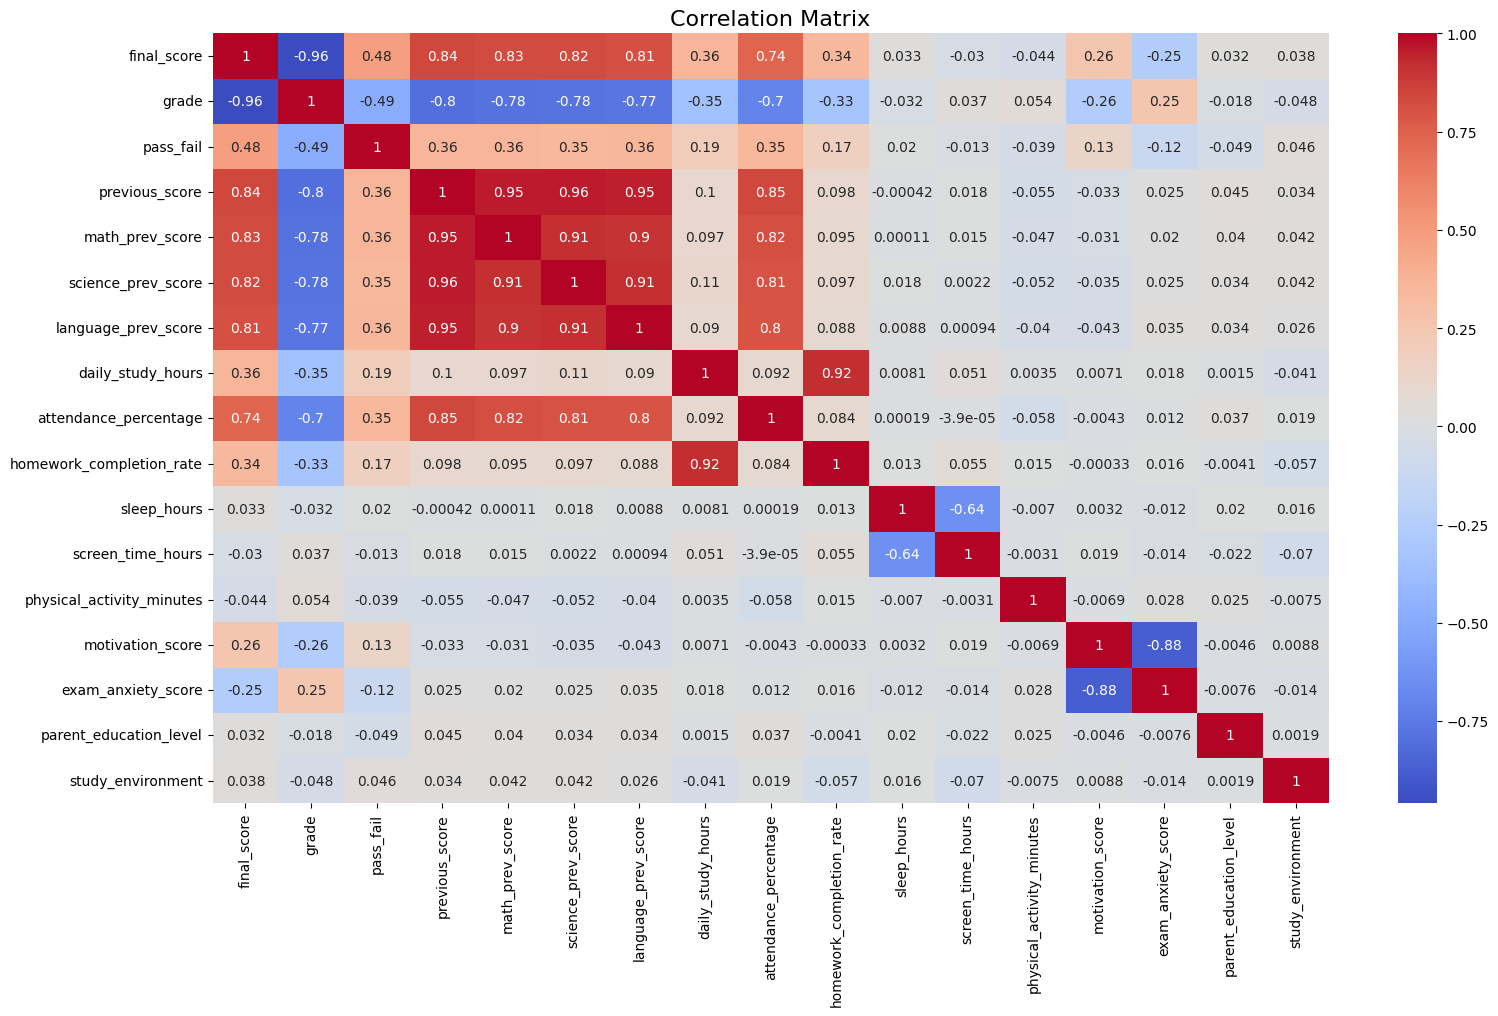

In [14]:
label_encoders = {}
for column in df.select_dtypes(include=['object']).columns:
    label_encoders[column] = LabelEncoder()
    df[column] = label_encoders[column].fit_transform(df[column])

correlation_matrix = df.corr(method='pearson')

plt.figure(figsize=(18, 10))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", cbar=True)
plt.title("Correlation Matrix", fontsize=16)
plt.show()

# <div style="display: inline-block; padding: 20px 20px; border-radius: 15px; background: linear-gradient(135deg, #d8bfd8, #8b008b); box-shadow: 3px 3px 8px rgba(0, 0, 0, 0.2); font-size: 35px; font-family: Arial, sans-serif; color: #ffffff; text-align: center;">Comparison of Machine Learning Model Performance</div>

In [15]:
X = df.drop('grade', axis=1)
y = df['grade'] 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    "Logistic Regression": LogisticRegression(max_iter=10000, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=3),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, random_state=42)
}

def evaluate_model(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)  
    y_pred = model.predict(X_test)  
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    
    return accuracy, precision, recall, f1

In [16]:
results = []

for name, model in models.items():
    accuracy, precision, recall, f1 = evaluate_model(model, X_train, X_test, y_train, y_test)
    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    })

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.900,0.902473,0.900,0.898483
1,KNN,0.690,0.674819,0.690,0.675290
2,Decision Tree,1.000,1.000000,1.000,1.000000
3,Random Forest,0.995,0.995069,0.995,0.994996
4,XGBoost,0.995,0.995069,0.995,0.994996


# <div style="display: inline-block; padding: 20px 20px; border-radius: 15px; background: linear-gradient(135deg, #d8bfd8, #8b008b); box-shadow: 3px 3px 8px rgba(0, 0, 0, 0.2); font-size: 35px; font-family: Arial, sans-serif; color: #ffffff; text-align: center;">Results</div>


Best Model (Final):
Model        Decision Tree
Accuracy               1.0
Precision              1.0
Recall                 1.0
F1-Score               1.0
Name: 2, dtype: object


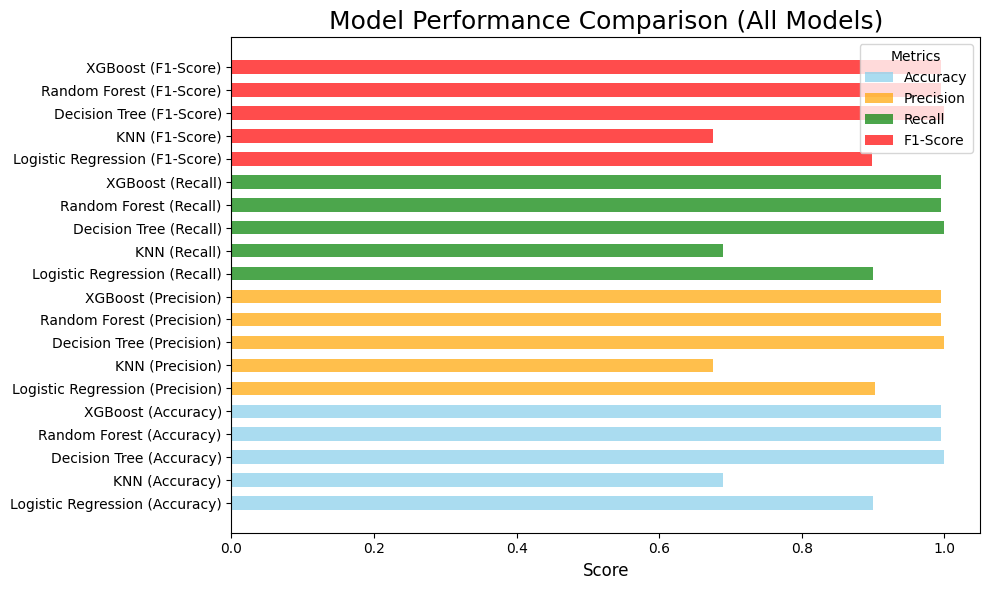


Optimal Model based on F1-Score: Decision Tree with F1-Score = 1.0000


In [17]:
best_model = results_df.loc[results_df['F1-Score'].idxmax()]
print("\nBest Model (Final):")
print(best_model)

metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]
colors = ["skyblue", "orange", "green", "red"]

fig, ax = plt.subplots(figsize=(10, 6))

for i, metric in enumerate(metrics):
    ax.barh(
        results_df['Model'] + f" ({metric})",
        results_df[metric],
        color=colors[i],
        alpha=0.7,
        label=metric,
        height=0.6
    )

ax.set_xlabel("Score", fontsize=12)
ax.set_title("Model Performance Comparison (All Models)", fontsize=18)
ax.legend(title="Metrics")

plt.tight_layout()
plt.show()

print(
    f"\nOptimal Model based on F1-Score: "
    f"{best_model['Model']} with F1-Score = {best_model['F1-Score']:.4f}"
)

In [18]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

print("Decision Tree - Classification Report")
print(classification_report(y_test, y_pred_dt, zero_division=0))

Decision Tree - Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        16
           1       1.00      1.00      1.00        38
           2       1.00      1.00      1.00        71
           3       1.00      1.00      1.00        60
           4       1.00      1.00      1.00        15

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



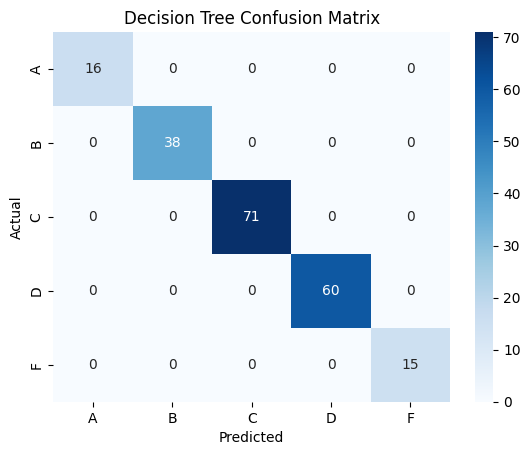

In [19]:
cm = confusion_matrix(y_test, y_pred_dt)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=grade_map.keys(),
            yticklabels=grade_map.keys())

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Decision Tree Confusion Matrix')
plt.show()

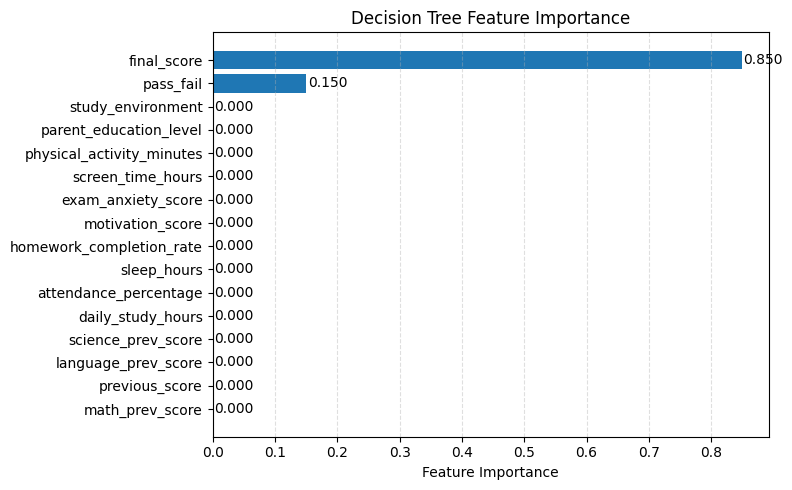

In [20]:
importances = dt_model.feature_importances_
feature_names = X.columns

indices = np.argsort(importances)

plt.figure(figsize=(8, 5))
bars = plt.barh(
    range(len(importances)),
    importances[indices]
)

plt.yticks(
    range(len(importances)),
    feature_names[indices]
)

plt.xlabel('Feature Importance')
plt.title('Decision Tree Feature Importance')

for i, v in enumerate(importances[indices]):
    plt.text(v + 0.002, i, f"{v:.3f}", va='center')

plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [21]:
X = df[['final_score', 'pass_fail']]
y = df['grade'] 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

print("Decision Tree - Classification Report")
print(classification_report(y_test, y_pred_dt, zero_division=0))

Decision Tree - Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        16
           1       1.00      1.00      1.00        38
           2       1.00      1.00      1.00        71
           3       1.00      1.00      1.00        60
           4       1.00      1.00      1.00        15

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



<div style="display: inline-block; padding: 10px 15px; border-radius: 20px; background: linear-gradient(135deg, #ff7f50, #ff1493); box-shadow: 5px 5px 15px rgba(0, 0, 0, 0.3); font-size: 30px; font-family: 'Helvetica Neue', Arial, sans-serif; color: #ffffff; text-align: center; border: 2px solid #ffffff;">Thanks !</div><br><br>

<h3> Feel free to ask any questions and use the code freely! </h3><br>
<h3> If this helped you, improved performance, or if you want fine-tuning tips, please vote! It really helps a lot!! </h3><br>
<div style="text-align: center;">
    <a href="https://www.kaggle.com/lko9911" target="_blank" style="display: inline-block; background-color: #3a86ff; color: #fff; text-decoration: none; padding: 5px 10px; border-radius: 10px; margin: 15px; font-size: 25px;">Kaggle</a>
    <a href="https://github.com/lko9911" target="_blank" style="display: inline-block; background-color: #ff8c00; color: #ffffff; text-decoration: none; padding: 5px 20px; border-radius: 15px; margin: 15px; border: 2px solid #ff4500; font-size: 25px; font-family: 'Arial', sans-serif; font-weight: bold; transition: all 0.3s ease;">GitHub</a></div>